# Mall Customers — Dataset Loading & Exploratory Data Analysis

In [209]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = r'C:\Users\patel\OneDrive\Desktop\R&W\Unsupervised Learning\Final Practical\final\Mall_Customers.csv'
df = pd.read_csv(DATA_PATH)

# Standardize column names for downstream analysis.
df = df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
})
df.columns

Index(['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore'], dtype='object')

## 1.1 Load & Inspect

In [210]:
print('Dataset shape:', df.shape)

print('\nData types and non-null counts:')
df.info()

print('\nFirst 10 rows:')
display(df.head(10))

print('\nMissing values:')
display(df.isnull().sum())

print('\nGender counts:')
print(df['Gender'].value_counts())

Dataset shape: (200, 5)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   AnnualIncome   200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

First 10 rows:


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Missing values:


CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


Gender counts:
Gender
Female    112
Male       88
Name: count, dtype: int64


## 1.2 Univariate Analysis

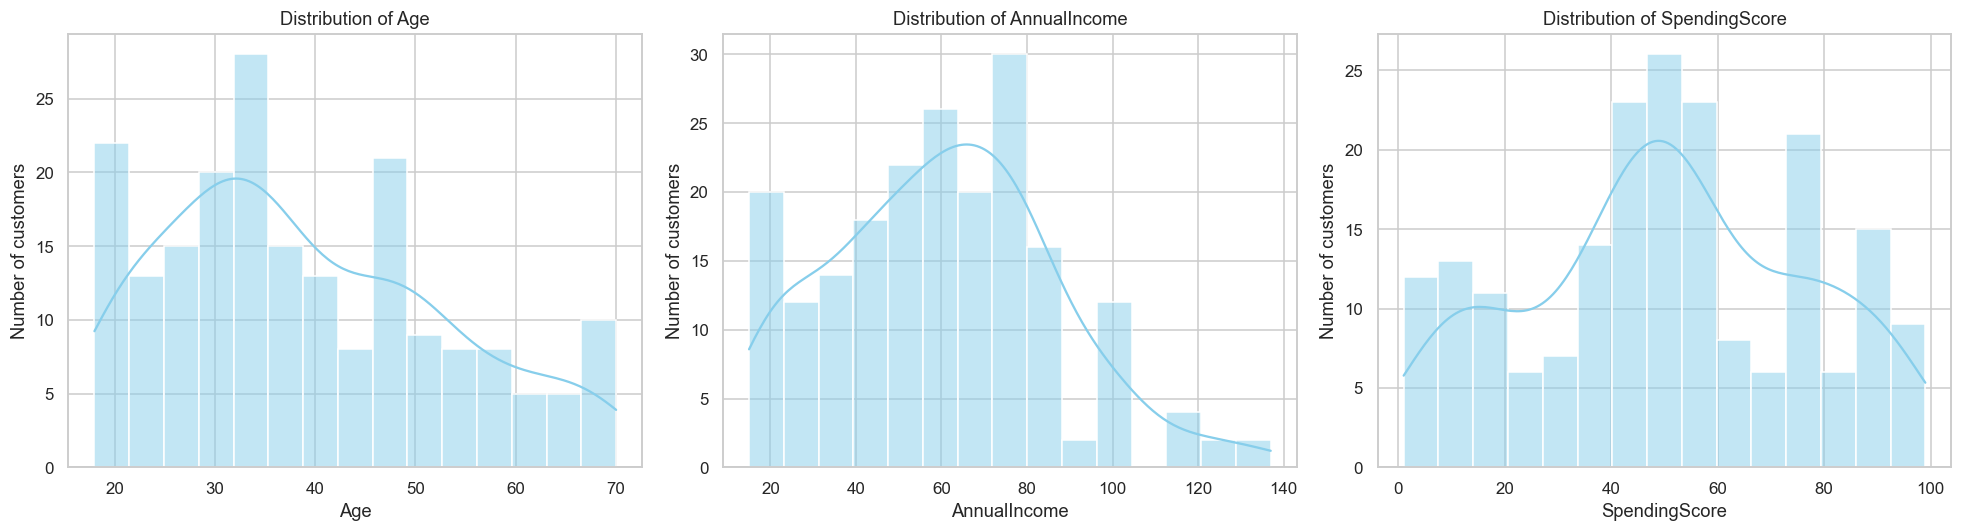

In [211]:
features = ['Age', 'AnnualIncome', 'SpendingScore']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, features):
    sns.histplot(data=df, x=feature, bins=15, kde=True, ax=ax, color='skyblue', edgecolor='white')
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

**Histogram comments:**

- **Age:** Broadly distributed from late teens to around 70, with more customers in the young-adult and middle-age ranges; it is not strongly symmetric.
- **AnnualIncome:** Values rise through the lower and middle ranges and taper at the high end, with a small high-income tail.
- **SpendingScore:** The distribution is spread across the full scale and shows concentrations toward both lower and higher scores, suggesting distinct customer spending behaviours.

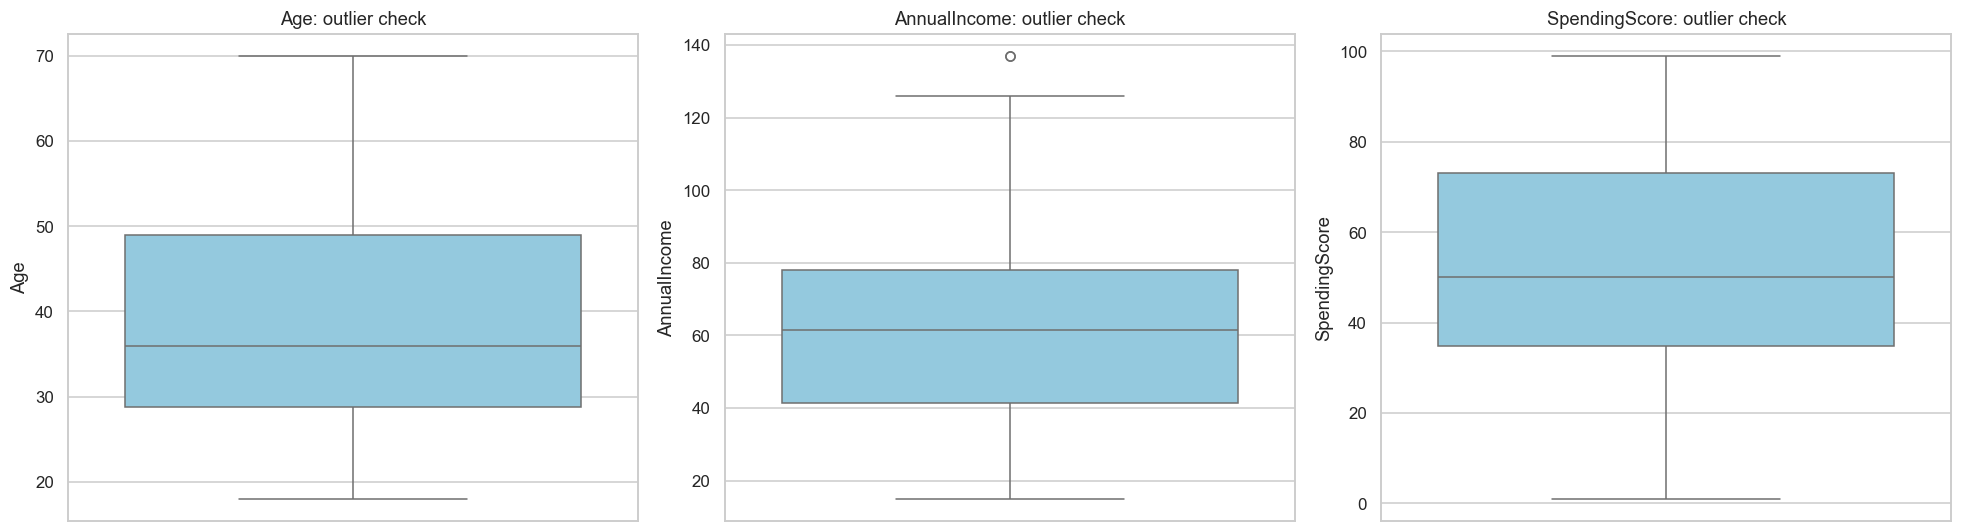

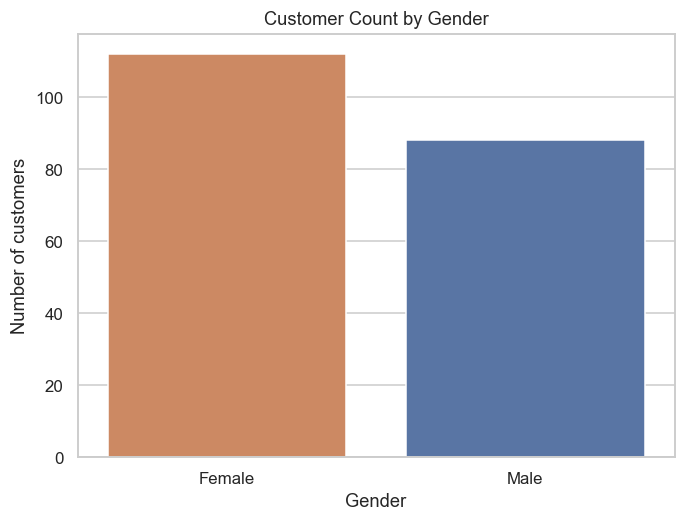

In [212]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, features):
    sns.boxplot(data=df, y=feature, ax=ax, color='skyblue')
    ax.set_title(f'{feature}: outlier check')
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Gender', hue='Gender', legend=False, order=['Female', 'Male'])
plt.title('Customer Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of customers')
plt.show()

**Gender balance:** The dataset is reasonably balanced, although Female customers (112; 56%) outnumber Male customers (88; 44%). The boxplots provide a visual check for extreme values before clustering.

## 1.3 Bivariate Analysis

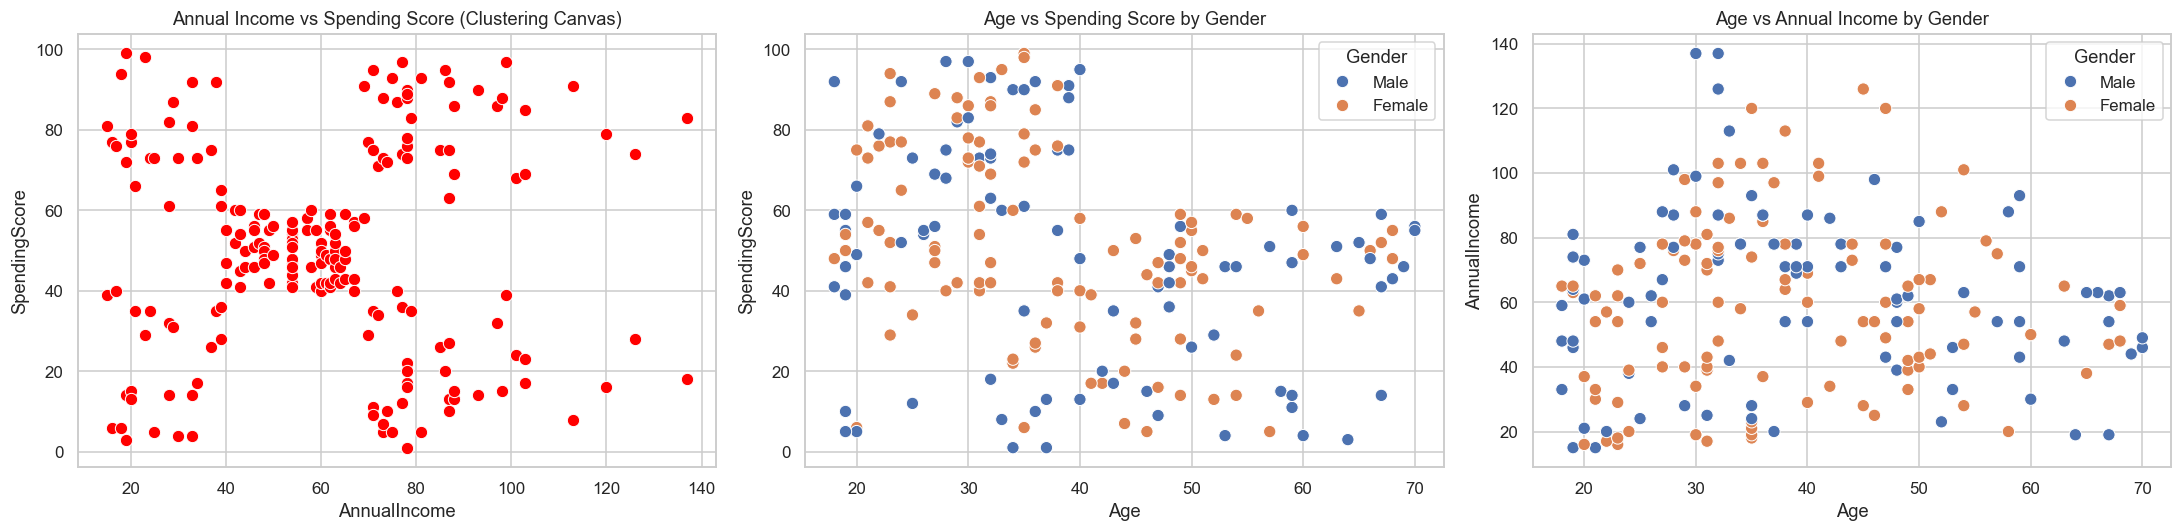

,CustomerID,Age,AnnualIncome,SpendingScore
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
AnnualIncome,0.977548,-0.012398,1.000000,0.009903
SpendingScore,0.013835,-0.327227,0.009903,1.000000


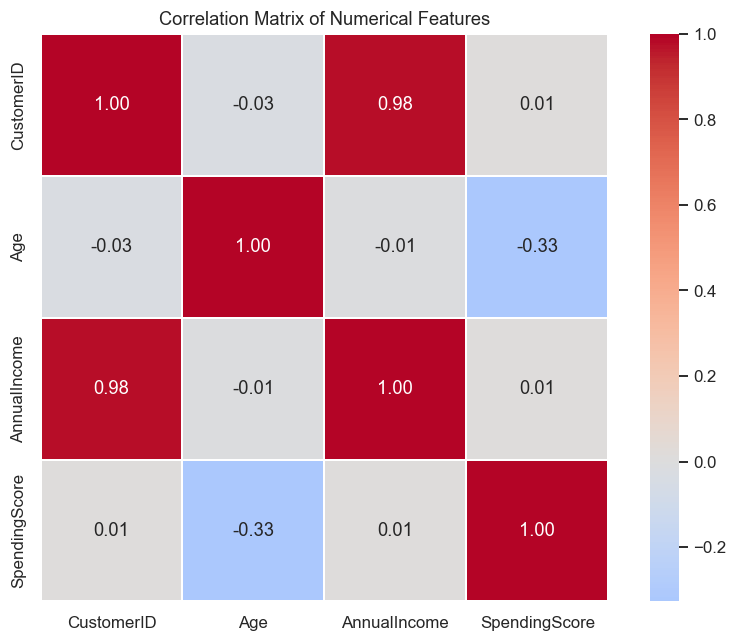

In [213]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', ax=axes[0], s=65, color='red')
axes[0].set_title('Annual Income vs Spending Score (Clustering Canvas)')

sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='Gender', ax=axes[1], s=65)
axes[1].set_title('Age vs Spending Score by Gender')

sns.scatterplot(data=df, x='Age', y='AnnualIncome', hue='Gender', ax=axes[2], s=65)
axes[2].set_title('Age vs Annual Income by Gender')

plt.tight_layout()
plt.show()

numeric_cols = df.select_dtypes(include='number').columns
correlation = df[numeric_cols].corr()
display(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 1.4 Gender-Based Summaries

,Age,AnnualIncome,SpendingScore
Gender,,,
Female,38.10,59.25,51.53
Male,39.81,62.23,48.51


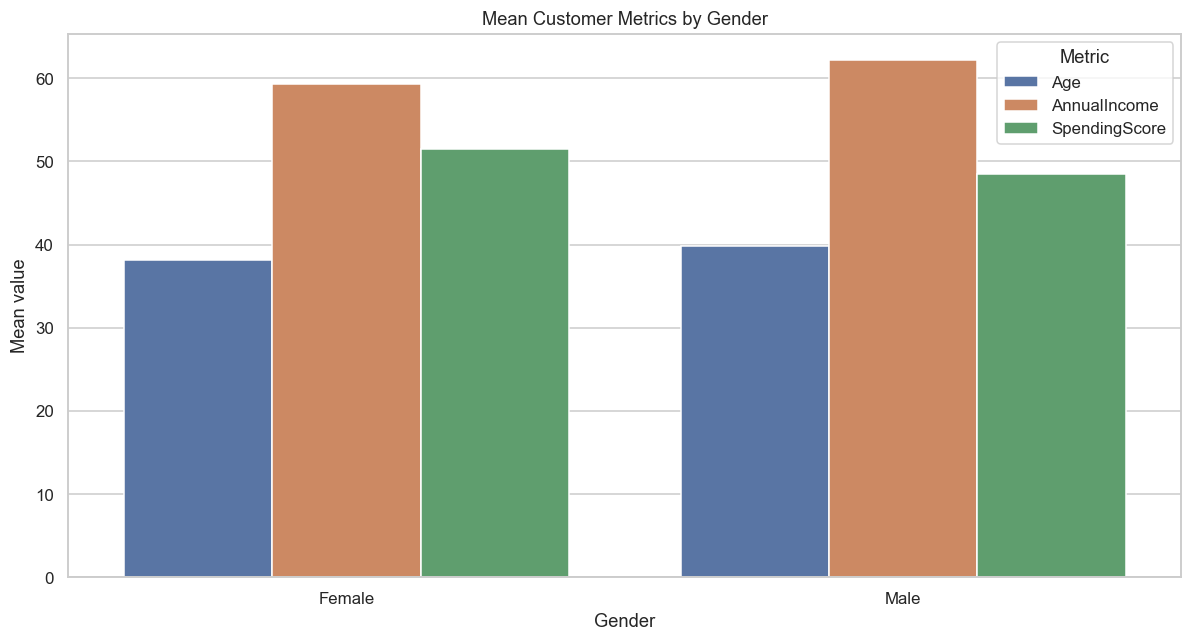

In [214]:
gender_means = df.groupby('Gender')[features].mean().reindex(['Female', 'Male'])
display(gender_means.round(2))

plot_means = gender_means.reset_index().melt(id_vars='Gender', var_name='Metric', value_name='Mean')
plt.figure(figsize=(11, 6))
sns.barplot(data=plot_means, x='Gender', y='Mean', hue='Metric')
plt.title('Mean Customer Metrics by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean value')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# Step 2: Feature Engineering & Preprocessing

## 2.1 Encoding

In [215]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# LabelEncoder orders the two labels alphabetically: Female = 0, Male = 1.
gender_encoder = LabelEncoder()
df['Gender_enc'] = gender_encoder.fit_transform(df['Gender'])

print('Label mapping:', dict(zip(gender_encoder.classes_, gender_encoder.transform(gender_encoder.classes_))))
display(df[['Gender', 'Gender_enc']].head(10))

Label mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Gender_enc
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0
5,Female,0
6,Female,0
7,Female,0
8,Male,1
9,Female,0


## 2.2 Binning

In [216]:
df['IncomeGroup'] = pd.qcut(df['AnnualIncome'], q=3, labels=['Low', 'Medium', 'High'])

# The supplied 41–55 and 55+ definitions overlap at age 55. These non-overlapping
# intervals assign 55 to Senior, so every row has exactly one AgeGroup.
df['AgeGroup'] = pd.cut(
    df['Age'], bins=[17, 25, 40, 54, float('inf')],
    labels=['Young', 'Adult', 'Middle-Aged', 'Senior']
)

df['SpendingCategory'] = pd.cut(
    df['SpendingScore'], bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

engineered_columns = ['IncomeGroup', 'AgeGroup', 'SpendingCategory']
for column in engineered_columns:
    print(f'\n{column} counts:')
    print(df[column].value_counts().sort_index())


IncomeGroup counts:
IncomeGroup
Low       70
Medium    64
High      66
Name: count, dtype: int64

AgeGroup counts:
AgeGroup
Young          38
Adult          84
Middle-Aged    48
Senior         30
Name: count, dtype: int64

SpendingCategory counts:
SpendingCategory
Low       49
Medium    94
High      57
Name: count, dtype: int64


**Balance analysis:** Review the printed counts before modelling. `IncomeGroup` uses quantile-based bins, so its groups should be approximately balanced (minor differences can occur because repeated income values cannot be split). `AgeGroup` and `SpendingCategory` use fixed ranges, so unequal group sizes reflect the natural distribution of the customers rather than a binning error.

## 2.3 Feature selection

In [217]:
# Core two-dimensional clustering canvas.
X_2d = df[['AnnualIncome', 'SpendingScore']].copy()

# The requested X_5d name is retained, although this specification contains four features.
X_5d = df[['Age', 'AnnualIncome', 'SpendingScore', 'Gender_enc']].copy()

print('X_2d shape:', X_2d.shape)
display(X_2d.head())
print('X_5d shape:', X_5d.shape)
display(X_5d.head())

X_2d shape: (200, 2)


,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


X_5d shape: (200, 4)


,Age,AnnualIncome,SpendingScore,Gender_enc
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## 2.4 Feature scalling

In [218]:
scaler_2d = StandardScaler()
scaler_5d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)
X_5d_scaled = scaler_5d.fit_transform(X_5d)

scaling_check_2d = pd.DataFrame({
    'mean': X_2d_scaled.mean(axis=0),
    'std': X_2d_scaled.std(axis=0)
}, index=X_2d.columns)
scaling_check_5d = pd.DataFrame({
    'mean': X_5d_scaled.mean(axis=0),
    'std': X_5d_scaled.std(axis=0)
}, index=X_5d.columns)

print('X_2d_scaled verification (mean ~ 0, std ~ 1):')
display(scaling_check_2d)
print('X_5d_scaled verification (mean ~ 0, std ~ 1):')
display(scaling_check_5d)

X_2d_scaled verification (mean ~ 0, std ~ 1):


,mean,std
AnnualIncome,-2.131628e-16,1.0
SpendingScore,-1.465494e-16,1.0


X_5d_scaled verification (mean ~ 0, std ~ 1):


,mean,std
Age,-1.021405e-16,1.0
AnnualIncome,-2.131628e-16,1.0
SpendingScore,-1.465494e-16,1.0
Gender_enc,3.108624e-17,1.0


### Why scaling is mandatory for distance-sensitive clustering

Distance-sensitive models such as K-Means, hierarchical clustering, and DBSCAN compare points using numerical distances. Without scaling, a feature with a larger numerical range can dominate those distances even when it is not more important. StandardScaler places each feature on a common scale (mean near 0 and standard deviation near 1), so the selected features contribute comparably to cluster formation.

# Step 3: K-Mean clustring

## 3.1 Elbow Method & Evaluation

,k,Inertia,SilhouetteScore
0,2,269.691,0.321
1,3,157.704,0.467
2,4,108.921,0.494
3,5,65.568,0.555
4,6,55.057,0.540
5,7,44.865,0.528
6,8,37.228,0.455
7,9,32.392,0.457
8,10,29.982,0.443


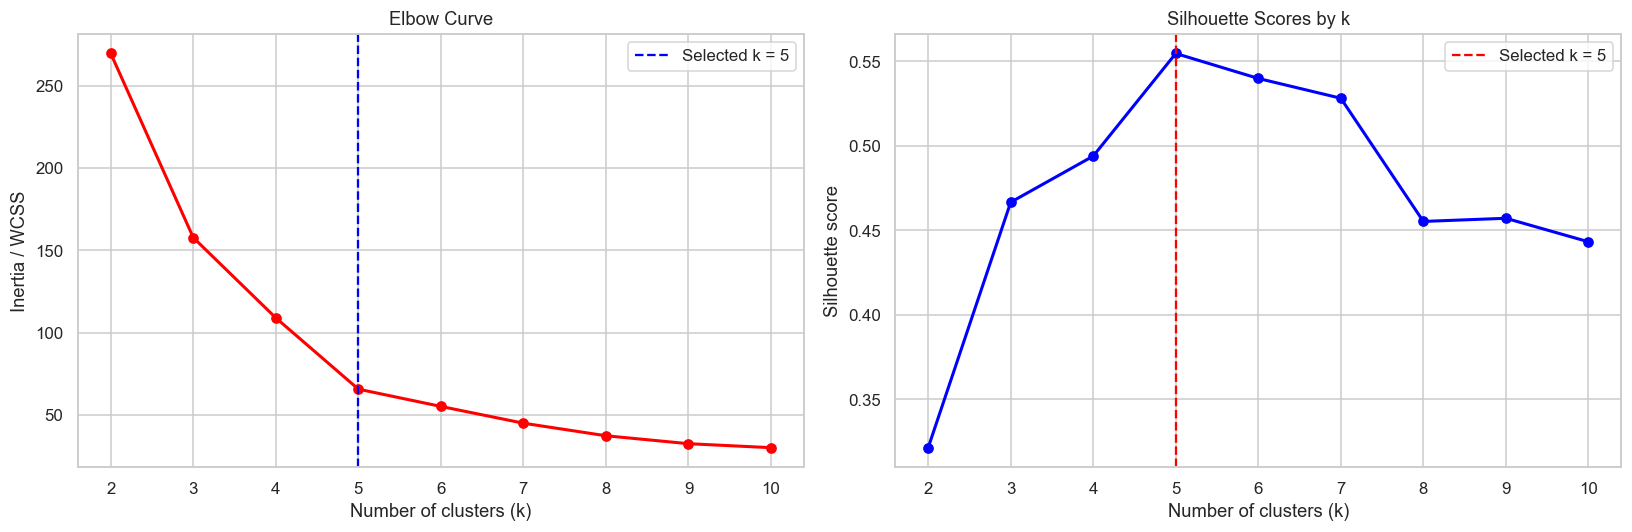

In [235]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

k_values = list(range(2, 11))
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = model.fit_predict(X_2d_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_2d_scaled, labels))

evaluation_results = pd.DataFrame({
    'k': k_values, 'Inertia': inertias, 'SilhouetteScore': silhouette_scores
})
display(evaluation_results.round(3))

optimal_k = 5
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(k_values, inertias, marker='o', linewidth=2, color='red')
axes[0].axvline(optimal_k, color='blue', linestyle='--', label='Selected k = 5')
axes[0].set(title='Elbow Curve', xlabel='Number of clusters (k)', ylabel='Inertia / WCSS')
axes[0].legend()

axes[1].plot(k_values, silhouette_scores, marker='o', linewidth=2, color='blue')
axes[1].axvline(optimal_k, color='red', linestyle='--', label='Selected k = 5')
axes[1].set(title='Silhouette Scores by k', xlabel='Number of clusters (k)', ylabel='Silhouette score')
axes[1].legend()
plt.tight_layout()
plt.show()

The elbow curve shows a substantial reduction in inertia up to **k=5**, after which each additional cluster produces a much smaller improvement. The silhouette score is highest at **k=5** (about 0.555), indicating the strongest combination of compact, well-separated groups among the tested configurations. The five resulting groups also match the five visually apparent income–spending segments identified during EDA, making k=5 both statistically and practically defensible.

## 3.2 Model training

In [220]:
kmeans_2d = KMeans(n_clusters=5, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['KMeans_Cluster'] = kmeans_2d.fit_predict(X_2d_scaled)

kmeans_5d = KMeans(n_clusters=5, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['KMeans_5D_Cluster'] = kmeans_5d.fit_predict(X_5d_scaled)

silhouette_2d = silhouette_score(X_2d_scaled, df['KMeans_Cluster'])
silhouette_5d = silhouette_score(X_5d_scaled, df['KMeans_5D_Cluster'])
comparison = pd.DataFrame({
    'Feature space': ['2D: Income + Spending', '5D label: Age + Income + Spending + Gender'],
    'Silhouette score': [silhouette_2d, silhouette_5d]
})
display(comparison.round(3))

,Feature space,Silhouette score
0,2D: Income + Spending,0.555
1,5D label: Age + Income + Spending + Gender,0.314


**Separation comparison:** The 2D income–spending model has the cleaner separation (silhouette ≈ 0.555) compared with the four-feature matrix stored as `X_5d` (silhouette ≈ 0.314). Adding age and encoded gender introduces variation that is useful for describing customers, but it makes the five clusters less compact and distinct under Euclidean distance.

## 3.3 Cluster visual

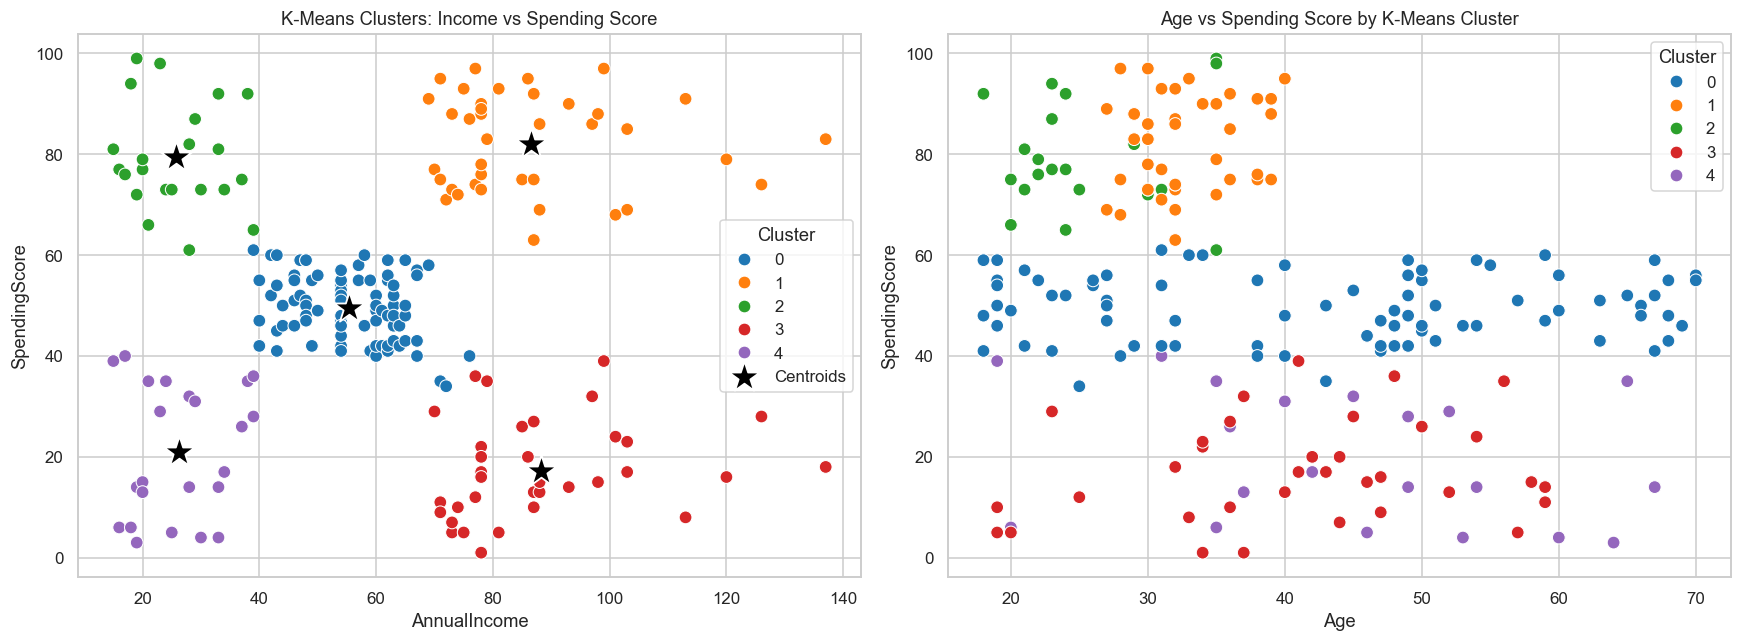

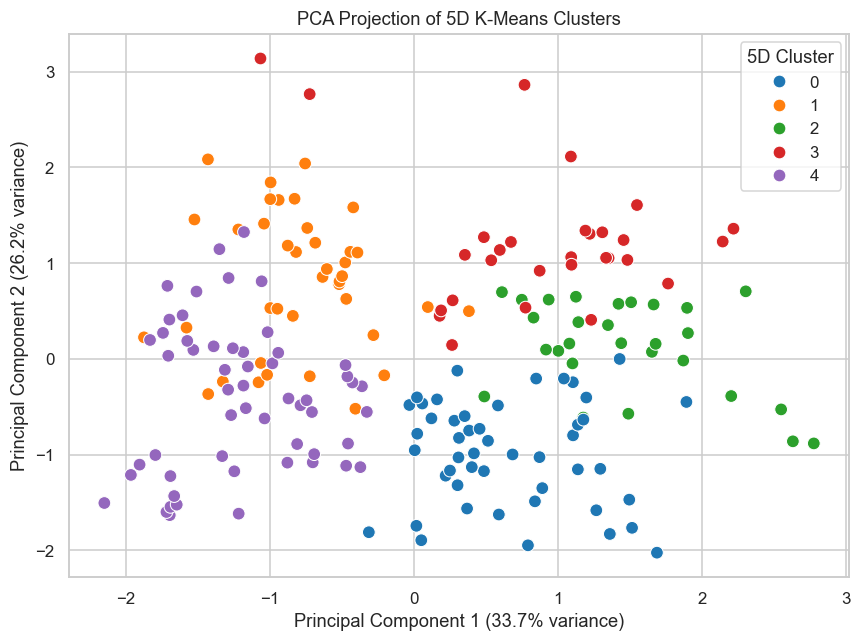

In [221]:
# Convert 2D centroids from standardized coordinates back to original units.
centroids_2d = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', hue='KMeans_Cluster', palette='tab10', s=70, ax=axes[0])
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='*', s=450, c='black', edgecolor='white', linewidth=1.2, label='Centroids')
axes[0].set_title('K-Means Clusters: Income vs Spending Score')
axes[0].legend(title='Cluster')

sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='KMeans_Cluster', palette='tab10', s=70, ax=axes[1])
axes[1].set_title('Age vs Spending Score by K-Means Cluster')
axes[1].legend(title='Cluster')
plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=42)
X_5d_pca = pca.fit_transform(X_5d_scaled)
explained_variance = pca.explained_variance_ratio_ * 100
pca_plot_df = pd.DataFrame({
    'PC1': X_5d_pca[:, 0], 'PC2': X_5d_pca[:, 1],
    'KMeans_5D_Cluster': df['KMeans_5D_Cluster']
})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='KMeans_5D_Cluster', palette='tab10', s=70)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}% variance)')
plt.title('PCA Projection of 5D K-Means Clusters')
plt.legend(title='5D Cluster')
plt.tight_layout()
plt.show()

## 3.4 Cluster profiling

In [222]:
profile_features = ['Age', 'AnnualIncome', 'SpendingScore']
cluster_profile = (df.groupby('KMeans_Cluster')[profile_features].mean()
                     .sort_values('SpendingScore', ascending=False))
gender_distribution = (pd.crosstab(df['KMeans_Cluster'], df['Gender'], normalize='index') * 100
                       ).rename(columns={'Male': '% Male', 'Female': '% Female'})
gender_distribution = gender_distribution.reindex(cluster_profile.index)

print('Mean unscaled customer measures by cluster (sorted by spending score):')
display(cluster_profile.round(2))
print('Gender distribution within each cluster:')
display(gender_distribution.round(2))

Mean unscaled customer measures by cluster (sorted by spending score):


,Age,AnnualIncome,SpendingScore
KMeans_Cluster,,,
1,32.69,86.54,82.13
2,25.27,25.73,79.36
0,42.72,55.30,49.52
4,45.22,26.30,20.91
3,41.11,88.20,17.11


Gender distribution within each cluster:


Gender,% Female,% Male
KMeans_Cluster,,
1,53.85,46.15
2,59.09,40.91
0,59.26,40.74
4,60.87,39.13
3,45.71,54.29


### Retail customer personas

- **Cluster 1 — Big Spenders:** This group has the highest spending score (about 82) alongside high income (about 87 k$) and is relatively young (about 33). They are an attractive premium segment for loyalty rewards, early product access, and high-value bundles.

- **Cluster 2 — Young Aspirers:** These are the youngest customers (about 25) with low income (about 26 k$) but very high spending (about 79). They respond strongly to the retail offering despite constrained means, so attainable aspirational products and targeted promotions may sustain engagement.

- **Cluster 0 — Careful Spenders:** This large middle segment has average income (about 55 k$), average spending (about 50), and an older average age (about 43). Their moderate behaviour suggests a practical, value-aware group that can be developed through relevant recommendations and dependable value.

- **Cluster 4 — Budget Shoppers:** This group has low income (about 26 k$) and low spending (about 21), with an average age around 45. Price reductions, essentials, and simple value propositions are more likely to resonate than premium-oriented campaigns.

- **Cluster 3 — Mature Savers:** These customers have the highest income (about 88 k$) but the lowest spending score (about 17), and are around 41 on average. Their spending restraint makes them a key reactivation opportunity; tailored high-quality offers may uncover unmet needs without relying on blanket discounts.

The exact gender percentages for each persona are shown in the table above; no persona is defined by gender alone.

# Step 4: Agglomerative Hierarchical Clustering

## 4.1 Dendrogram Analysis

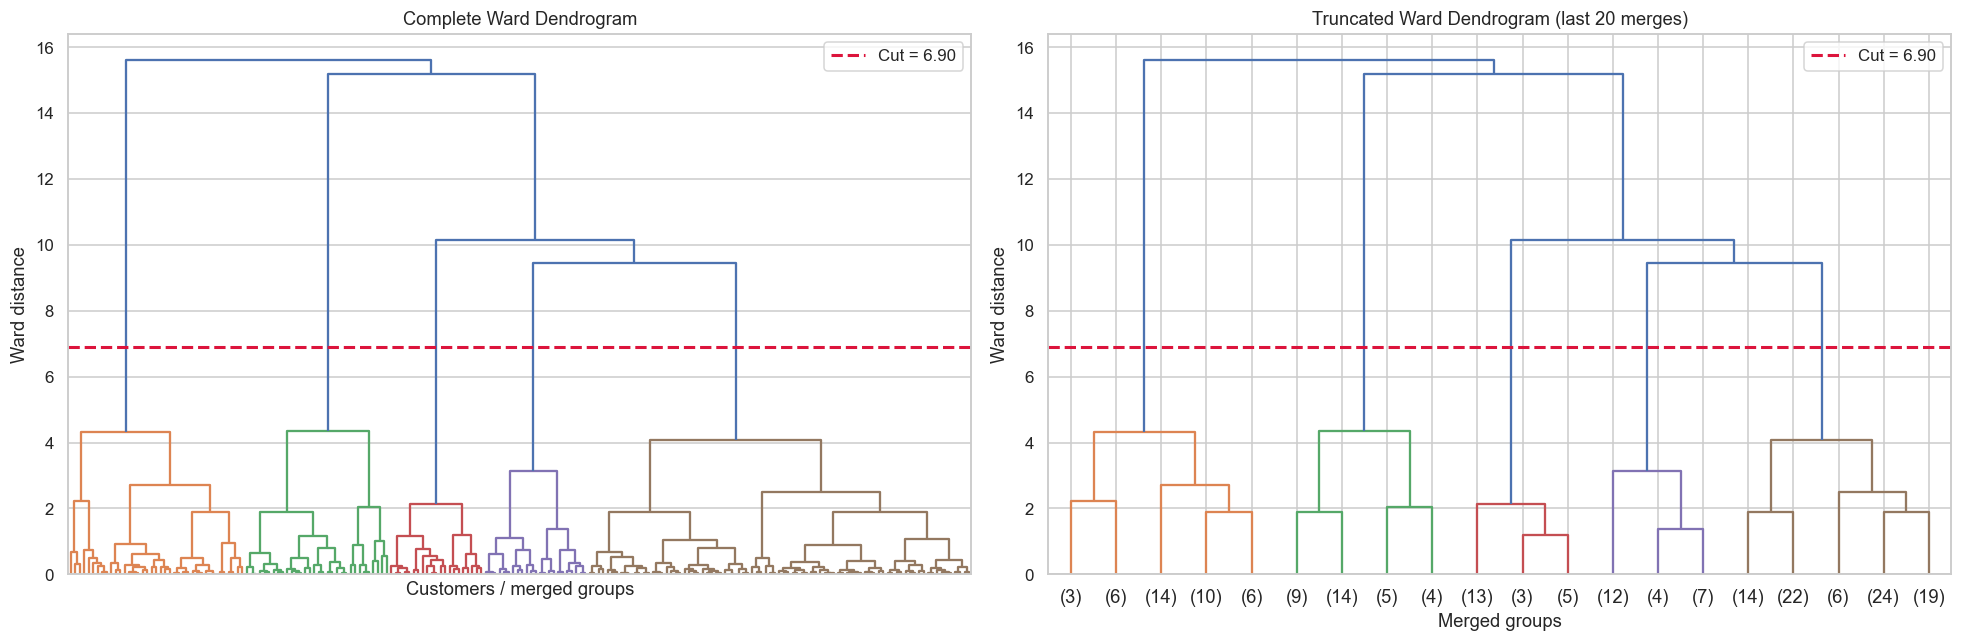

Cut-line distance threshold: 6.9039
This threshold natively yields 5 clusters.


In [223]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

linkage_matrix = linkage(X_2d_scaled, method='ward')
# Midpoint between the 5-cluster and 4-cluster merges.
cut_threshold = (linkage_matrix[194, 2] + linkage_matrix[195, 2]) / 2

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
dendrogram(linkage_matrix, ax=axes[0], no_labels=True, color_threshold=cut_threshold)
axes[0].axhline(cut_threshold, color='crimson', linestyle='--', linewidth=2, label=f'Cut = {cut_threshold:.2f}')
axes[0].set(title='Complete Ward Dendrogram', xlabel='Customers / merged groups', ylabel='Ward distance')
axes[0].legend()

dendrogram(linkage_matrix, truncate_mode='lastp', p=20, ax=axes[1], color_threshold=cut_threshold)
axes[1].axhline(cut_threshold, color='crimson', linestyle='--', linewidth=2, label=f'Cut = {cut_threshold:.2f}')
axes[1].set(title='Truncated Ward Dendrogram (last 20 merges)', xlabel='Merged groups', ylabel='Ward distance')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Cut-line distance threshold: {cut_threshold:.4f}')
print('This threshold natively yields 5 clusters.')

**Dendrogram decision:** The horizontal cut is placed at **6.9039** Ward-distance units, midway through the clear separation between the final within-five-group merge (4.3544) and the next merge (9.4534). It natively produces **5 clusters**.

## 4.2 Model Training & Metrics Comparison

In [224]:
linkages = ['ward', 'complete', 'average']
agg_labels = {}
agg_scores = {}

for linkage_name in linkages:
    model = AgglomerativeClustering(n_clusters=5, linkage=linkage_name)
    agg_labels[linkage_name] = model.fit_predict(X_2d_scaled)
    agg_scores[linkage_name] = silhouette_score(X_2d_scaled, agg_labels[linkage_name])

best_linkage = max(agg_scores, key=agg_scores.get)
df['Agg_Cluster'] = agg_labels[best_linkage]
metrics_df = pd.DataFrame({'Linkage': linkages, 'Silhouette Score': [agg_scores[x] for x in linkages]})
display(metrics_df.style.format({'Silhouette Score': '{:.3f}'}).set_caption('Agglomerative clustering comparison'))
print(f'Highest-performing linkage: {best_linkage}')

,Linkage,Silhouette Score
0,ward,0.554
1,complete,0.553
2,average,0.479


Highest-performing linkage: ward


| Linkage | Silhouette Score |
|---|---:|
| Ward | 0.554 |
| Complete | 0.553 |
| Average | 0.479 |

**Ward** is selected because it has the highest silhouette score.

## 4.3 Visualization & Alignment Evaluation

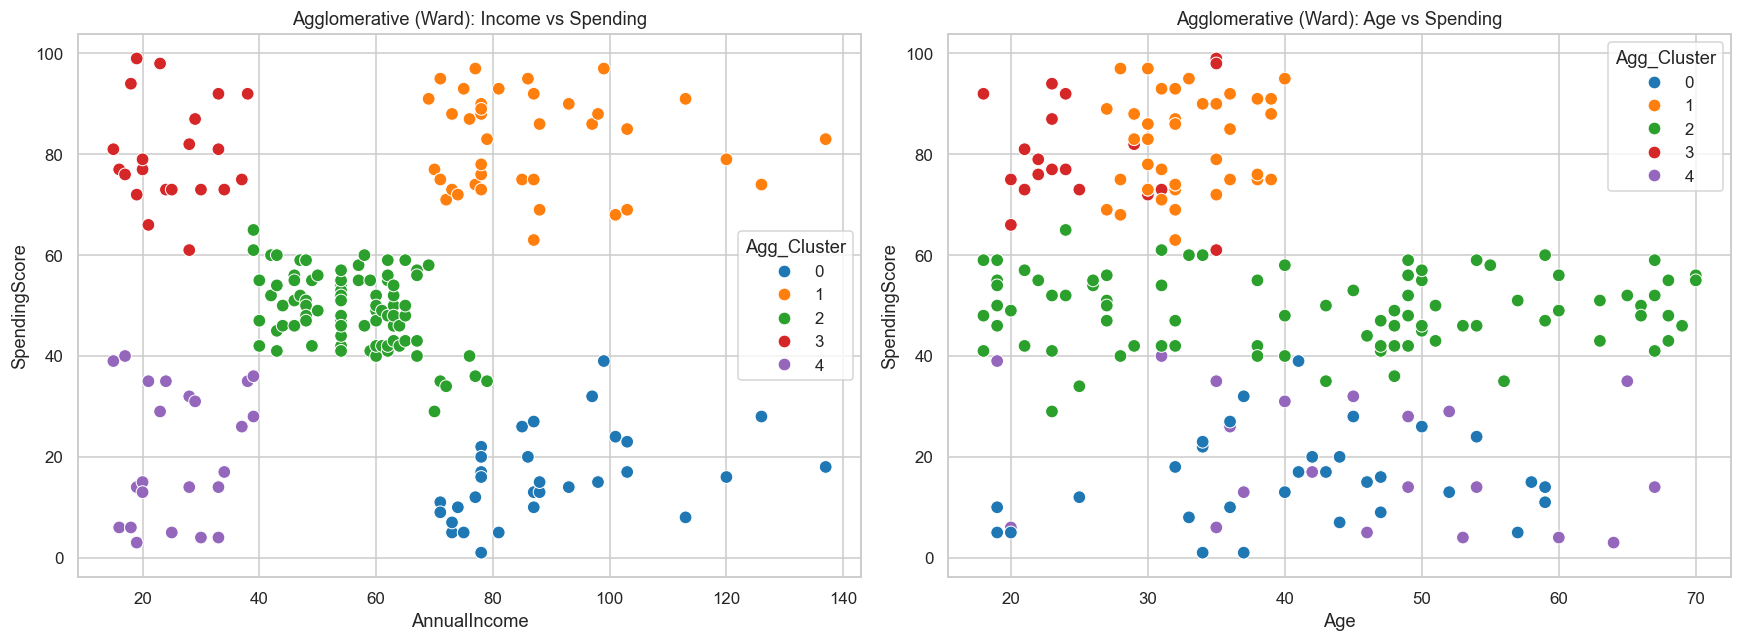

Agglomerative cluster mean profiles:


,Age,AnnualIncome,SpendingScore
Agg_Cluster,,,
1,32.69,86.54,82.13
3,25.33,25.10,80.05
2,42.48,55.81,49.13
4,45.22,26.30,20.91
0,41.00,89.41,15.59


K-Means vs Agglomerative cross-tabulation:


Agg_Cluster,0,1,2,3,4
KMeans_Cluster,,,,,
0,0,0,81,0,0
1,0,39,0,0,0
2,0,0,1,21,0
3,32,0,3,0,0
4,0,0,0,0,23


Best label-aligned agreement: 98.00% (196/200 customers)


In [225]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x='AnnualIncome', y='SpendingScore', hue='Agg_Cluster', palette='tab10', s=70, ax=axes[0])
axes[0].set_title(f'Agglomerative ({best_linkage.title()}): Income vs Spending')
sns.scatterplot(data=df, x='Age', y='SpendingScore', hue='Agg_Cluster', palette='tab10', s=70, ax=axes[1])
axes[1].set_title(f'Agglomerative ({best_linkage.title()}): Age vs Spending')
plt.tight_layout()
plt.show()

agg_profile = (df.groupby('Agg_Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean()
                 .sort_values('SpendingScore', ascending=False))
print('Agglomerative cluster mean profiles:')
display(agg_profile.round(2))

# Cluster IDs are arbitrary, so use the best one-to-one label mapping for agreement.
alignment_table = pd.crosstab(df['KMeans_Cluster'], df['Agg_Cluster'])
from scipy.optimize import linear_sum_assignment
row_idx, col_idx = linear_sum_assignment(-alignment_table.to_numpy())
matched_customers = alignment_table.to_numpy()[row_idx, col_idx].sum()
agreement_pct = matched_customers / len(df) * 100
print('K-Means vs Agglomerative cross-tabulation:')
display(alignment_table)
print(f'Best label-aligned agreement: {agreement_pct:.2f}% ({matched_customers}/{len(df)} customers)')

# Step 5: DBSCAN clustering

## 5.1 Hyperparameter Tuning via k-NN

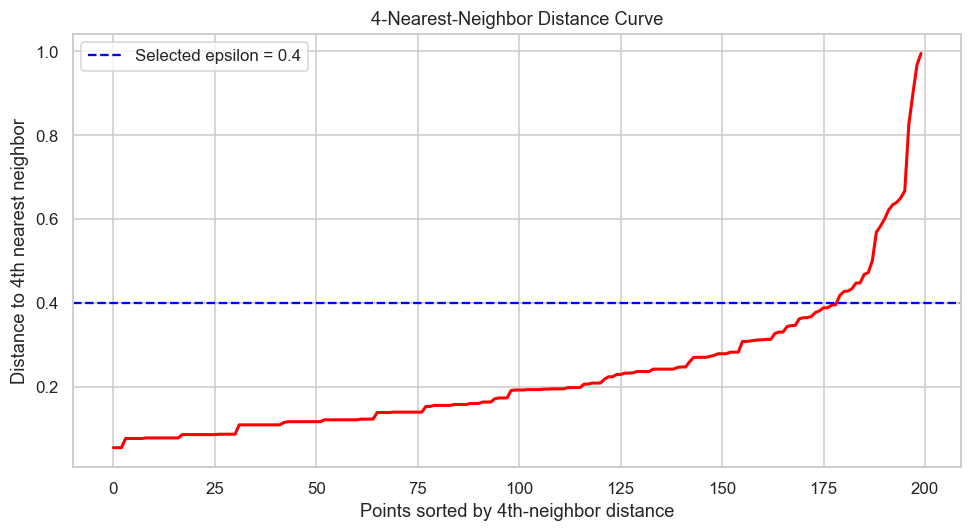

In [226]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np

neighbors = NearestNeighbors(n_neighbors=4).fit(X_2d_scaled)
distances, _ = neighbors.kneighbors(X_2d_scaled)
fourth_neighbor_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(fourth_neighbor_distances, color='red', linewidth=2)
plt.axhline(0.4, color='blue', linestyle='--', label='Selected epsilon = 0.4')
plt.title('4-Nearest-Neighbor Distance Curve')
plt.xlabel('Points sorted by 4th-neighbor distance')
plt.ylabel('Distance to 4th nearest neighbor')
plt.legend()
plt.tight_layout()
plt.show()

**Epsilon selection:** The curve bends upward at roughly **epsilon = 0.4**. Below this level, many otherwise nearby observations are separated; above it, separate dense regions begin to merge, so 0.4 is a sensible initial density radius.

## 5.2 Core Model Training

In [227]:
initial_dbscan = DBSCAN(eps=0.4, min_samples=4, metric='euclidean')
df['DBSCAN_Cluster'] = initial_dbscan.fit_predict(X_2d_scaled)

initial_noise_count = (df['DBSCAN_Cluster'] == -1).sum()
initial_noise_pct = initial_noise_count / len(df) * 100
initial_cluster_count = len(set(df['DBSCAN_Cluster'])) - int(-1 in set(df['DBSCAN_Cluster']))
print(f'Clusters excluding noise: {initial_cluster_count}')
print(f'Noise points: {initial_noise_count} ({initial_noise_pct:.2f}%)')

Clusters excluding noise: 3
Noise points: 14 (7.00%)


## 5.3 Grid Search Tuning

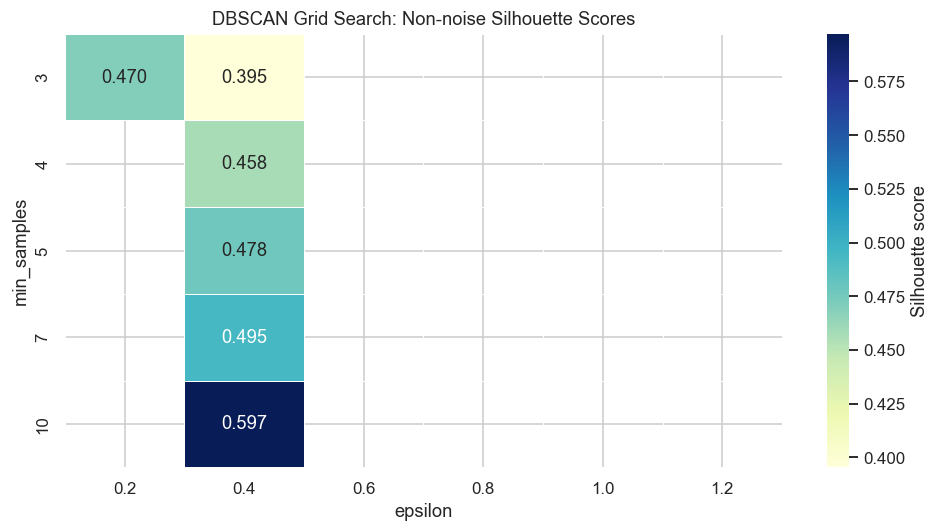

Best configuration: eps=0.4, min_samples=10, silhouette=0.597


In [228]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 7, 10]
grid_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit_predict(X_2d_scaled)
        non_noise = labels != -1
        cluster_count = len(set(labels[non_noise]))
        noise_pct = (1 - non_noise.mean()) * 100
        score = np.nan
        if cluster_count >= 2 and noise_pct < 30:
            score = silhouette_score(X_2d_scaled[non_noise], labels[non_noise])
        grid_results.append({'eps': eps, 'min_samples': min_samples, 'clusters': cluster_count, 'noise_pct': noise_pct, 'silhouette': score})

grid_results_df = pd.DataFrame(grid_results)
score_grid = grid_results_df.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(9, 5))
sns.heatmap(score_grid, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Silhouette score'})
plt.title('DBSCAN Grid Search: Non-noise Silhouette Scores')
plt.xlabel('epsilon')
plt.ylabel('min_samples')
plt.tight_layout()
plt.show()

best_row = grid_results_df.loc[grid_results_df['silhouette'].idxmax()]
best_eps = best_row['eps']
best_min_samples = int(best_row['min_samples'])
best_score = best_row['silhouette']
final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='euclidean')
df['DBSCAN_Cluster'] = final_dbscan.fit_predict(X_2d_scaled)
print(f'Best configuration: eps={best_eps:.1f}, min_samples={best_min_samples}, silhouette={best_score:.3f}')

## 5.4 Visualization & Nuance Analysis


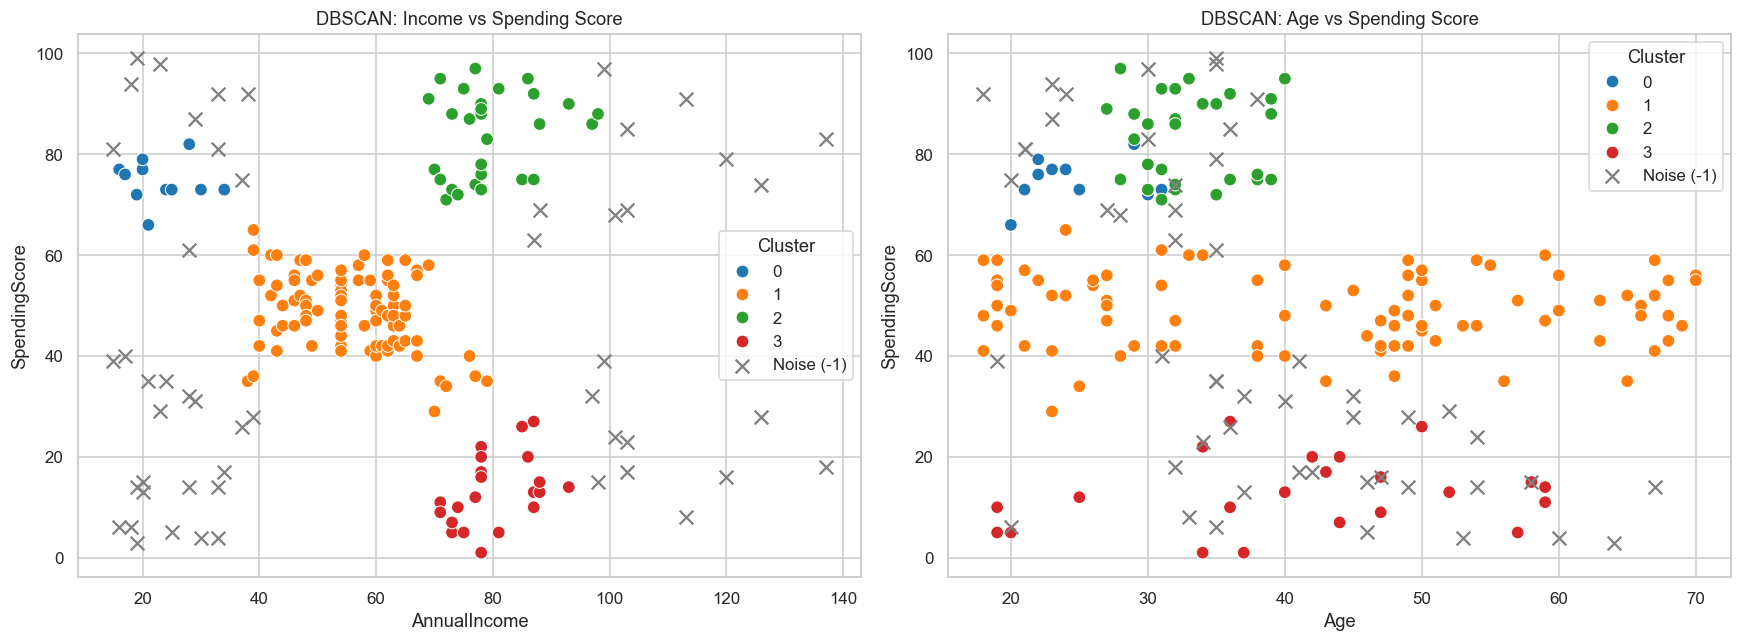

Mean profiles for core clusters:


,Age,AnnualIncome,SpendingScore
DBSCAN_Cluster,,,
0,25.18,23.09,74.64
1,42.80,55.41,48.82
2,32.93,79.24,83.62
3,41.00,80.18,12.68


Mean profile for noise points:


,Noise mean
Age,37.49
AnnualIncome,58.33
SpendingScore,44.47


In [229]:
core_points = df[df['DBSCAN_Cluster'] != -1]
noise_points = df[df['DBSCAN_Cluster'] == -1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=core_points, x='AnnualIncome', y='SpendingScore', hue='DBSCAN_Cluster', palette='tab10', s=70, ax=axes[0])
axes[0].scatter(noise_points['AnnualIncome'], noise_points['SpendingScore'], c='grey', marker='x', s=80, label='Noise (-1)')
axes[0].set_title('DBSCAN: Income vs Spending Score')
axes[0].legend(title='Cluster')

sns.scatterplot(data=core_points, x='Age', y='SpendingScore', hue='DBSCAN_Cluster', palette='tab10', s=70, ax=axes[1])
axes[1].scatter(noise_points['Age'], noise_points['SpendingScore'], c='grey', marker='x', s=80, label='Noise (-1)')
axes[1].set_title('DBSCAN: Age vs Spending Score')
axes[1].legend(title='Cluster')
plt.tight_layout()
plt.show()

core_profile = core_points.groupby('DBSCAN_Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean().round(2)
noise_profile = noise_points[['Age', 'AnnualIncome', 'SpendingScore']].mean().round(2)
print('Mean profiles for core clusters:')
display(core_profile)
print('Mean profile for noise points:')
display(noise_profile.to_frame('Noise mean'))

### Interpretation

DBSCAN forms clusters only where it finds enough nearby points, so it can keep dense customer groups separate without forcing every customer into a segment. Points in sparse transition areas—often average shoppers between the stronger income-and-spending groups—may be labelled as noise even though they are not extreme values. This is useful because noise here means *not part of a sufficiently dense cluster*, rather than necessarily being an error or an unusual customer.

# Step 6: Algorithm Comparison & Business Interpretation

## 6.1 Internal Metrics Comparison

In [230]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

model_specs = [
    ('K-Means', 'k=5; k-means++; n_init=20; max_iter=500', df['KMeans_Cluster'].to_numpy()),
    ('Agglomerative', f'n=5; linkage={best_linkage}', df['Agg_Cluster'].to_numpy()),
    ('DBSCAN', f'eps={best_eps:.1f}; min_samples={best_min_samples}', df['DBSCAN_Cluster'].to_numpy())
]
metric_rows = []
for algorithm, parameters, labels in model_specs:
    non_noise = labels != -1
    X_eval, labels_eval = X_2d_scaled[non_noise], labels[non_noise]
    metric_rows.append({
        'Algorithm Name': algorithm, 'Final Hyperparameters Used': parameters,
        'Number of Clusters Found': len(set(labels_eval)),
        'Silhouette Score': silhouette_score(X_eval, labels_eval),
        'Davies-Bouldin Index': davies_bouldin_score(X_eval, labels_eval),
        'Calinski-Harabasz Index': calinski_harabasz_score(X_eval, labels_eval),
        '% of Points Classified as Noise': (1 - non_noise.mean()) * 100
    })

comparison_metrics = pd.DataFrame(metric_rows)
display(comparison_metrics.style.format({'Silhouette Score': '{:.3f}', 'Davies-Bouldin Index': '{:.3f}', 'Calinski-Harabasz Index': '{:.2f}', '% of Points Classified as Noise': '{:.1f}%'}))

,Algorithm Name,Final Hyperparameters Used,Number of Clusters Found,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,% of Points Classified as Noise
0,K-Means,k=5; k-means++; n_init=20; max_iter=500,5,0.555,0.572,248.65,0.0%
1,Agglomerative,n=5; linkage=ward,5,0.554,0.578,244.41,0.0%
2,DBSCAN,eps=0.4; min_samples=10,4,0.597,0.473,263.61,25.5%


### Structured ranking

1. **K-Means — recommended for deployment:** Five interpretable segments, every customer assigned, and excellent separation (silhouette about 0.555; Davies-Bouldin about 0.572).
2. **Agglomerative Ward:** Almost identical quality (silhouette about 0.554), validating the structure, but less practical for assigning future customers.
3. **DBSCAN:** The retained core points have strong quality metrics, but about 25.5% of customers are noise and only four clusters remain, so it is better as a diagnostic complement.

*DBSCAN quality metrics are calculated only on non-noise points and are therefore not directly like-for-like with the all-customer results.*

## 6.2 K-Means Stability Check

In [231]:
stability_seeds = [0, 7, 21, 42, 99]
stability_scores = []
for seed in stability_seeds:
    repeat_model = KMeans(n_clusters=5, init='k-means++', n_init=20, max_iter=500, random_state=seed)
    repeat_labels = repeat_model.fit_predict(X_2d_scaled)
    stability_scores.append(silhouette_score(X_2d_scaled, repeat_labels))
stability_df = pd.DataFrame({'random_state': stability_seeds, 'Silhouette Score': stability_scores})
display(stability_df.style.format({'Silhouette Score': '{:.6f}'}))
print(f'Mean ± standard deviation: {np.mean(stability_scores):.6f} ± {np.std(stability_scores):.6f}')

,random_state,Silhouette Score
0,0,0.554657
1,7,0.554657
2,21,0.554657
3,42,0.554657
4,99,0.554657


Mean ± standard deviation: 0.554657 ± 0.000000


K-Means is highly stable because the income–spending data form clean, well-separated, compact groups, so different centroid starts converge to the same segmentation. K-means++ initialization and 20 restarts further reduce sensitivity to an unlucky initial placement.

# Step 7: Pipeline, Deployment & Submission Deliverables

## 7.1 Production Pipeline Saving & Testing

In [232]:
import joblib
from pathlib import Path

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
SCALER_PATH = OUTPUT_DIR / 'mall_scaler.pkl'
MODEL_PATH = OUTPUT_DIR / 'mall_segmentation_model.pkl'

# The 2D K-Means model is the selected deployable model.
joblib.dump(scaler_2d, SCALER_PATH)
joblib.dump(kmeans_2d, MODEL_PATH)
print(f'Saved scaler: {SCALER_PATH}')
print(f'Saved model: {MODEL_PATH}')

Saved scaler: outputs\mall_scaler.pkl
Saved model: outputs\mall_segmentation_model.pkl


In [233]:
deployment_profiles = df.groupby('KMeans_Cluster')[['AnnualIncome', 'SpendingScore']].mean()
persona_map = {}
for cluster_id, profile in deployment_profiles.iterrows():
    income, spending = profile['AnnualIncome'], profile['SpendingScore']
    if income >= 60 and spending >= 65:
        persona_map[cluster_id] = 'Big Spenders'
    elif income < 45 and spending >= 65:
        persona_map[cluster_id] = 'Young Aspirers'
    elif income < 45 and spending < 35:
        persona_map[cluster_id] = 'Budget Shoppers'
    elif income >= 60 and spending < 35:
        persona_map[cluster_id] = 'Mature Savers'
    else:
        persona_map[cluster_id] = 'Careful Spenders'
print('Cluster-to-persona mapping:', persona_map)

def classify_shopper(age, income, spending, gender=None):
    """Return a 2D K-Means segment. Age and gender are retained for API compatibility."""
    loaded_scaler = joblib.load(SCALER_PATH)
    loaded_model = joblib.load(MODEL_PATH)
    raw_features = pd.DataFrame([[income, spending]], columns=['AnnualIncome', 'SpendingScore'])
    cluster = int(loaded_model.predict(loaded_scaler.transform(raw_features))[0])
    return {
        'age': age, 'gender': gender, 'annual_income_k$': income, 'spending_score': spending,
        'cluster': cluster, 'persona': persona_map[cluster]
    }

test_shoppers = [
    (22, 30, 85, 'Female'), (35, 92, 88, 'Male'), (45, 25, 18, 'Female'),
    (42, 90, 16, 'Male'), (39, 55, 50, 'Female')
]
for shopper in test_shoppers:
    result = classify_shopper(*shopper)
    display(f"Age {result['age']}, {result['gender']}, income {result['annual_income_k$']}k, spending {result['spending_score']} -> Cluster {result['cluster']}: {result['persona']}")

Cluster-to-persona mapping: {0: 'Careful Spenders', 1: 'Big Spenders', 2: 'Young Aspirers', 3: 'Mature Savers', 4: 'Budget Shoppers'}


'Age 22, Female, income 30k, spending 85 -> Cluster 2: Young Aspirers'

'Age 35, Male, income 92k, spending 88 -> Cluster 1: Big Spenders'

'Age 45, Female, income 25k, spending 18 -> Cluster 4: Budget Shoppers'

'Age 42, Male, income 90k, spending 16 -> Cluster 3: Mature Savers'

'Age 39, Female, income 55k, spending 50 -> Cluster 0: Careful Spenders'

**Inference note:** The deployed model intentionally uses only income and spending because this 2D feature space gave the clearest and most stable segmentation. Age and gender are accepted by the function for a future API contract and can support personalisation, but they do not alter the present cluster assignment.

In [234]:
REPORT_PATH = OUTPUT_DIR / 'summary_report.md'
REPORT_PATH.parent.mkdir(exist_ok=True)
summary_report = '''# Mall Customer Segmentation: Executive Summary

## Retail business objective

Nexus Malls / Phoenix Marketcity needs a practical way to turn broad customer behaviour into targeted retail decisions. This project segments customers using annual income and spending score, allowing operations teams to plan tenant mixes, promotions, loyalty benefits, and physical layouts around meaningful shopper needs. The objective is to direct the right offer, experience, and zone to the right customer at the right moment.

## Feature-space review

Two feature spaces were evaluated. The primary two-dimensional space used Annual Income and Spending Score, the clearest behavioural canvas for commercial segmentation. A broader matrix added Age and encoded Gender; it supplied useful descriptive context but reduced group clarity under Euclidean distance. The 2D K-Means solution achieved a silhouette score of approximately 0.555, while the expanded feature set scored approximately 0.314. Age and gender should therefore inform persona messaging and reporting, rather than determine the first production cluster assignment.

## Model decision

K-Means with five clusters is recommended for deployment. It assigns every customer to an actionable segment, produces compact and well-separated groups, and remains stable when rerun with different initial seeds. Ward agglomerative clustering reached almost the same quality, validating that the pattern is real, but K-Means is easier to apply repeatedly to new shoppers. DBSCAN produced strong scores for dense core points; however, it classified roughly one quarter of customers as noise. That makes DBSCAN valuable for monitoring transitional customers, not as the main operational engine.

## Shopper personas

Big Spenders combine high income with high spending and merit premium-brand access, concierge experiences, and luxury pop-ups. Young Aspirers have lower income but high spending, making trend-led events, instalments, and attainable premium offers relevant. Careful Spenders sit in the middle on both income and spending and respond to dependable value, family bundles, and cross-store recommendations. Budget Shoppers have low income and low spending, so entrance-adjacent value stores, BOGO campaigns, and mobile coupons are appropriate. Mature Savers have high income but low spending; personalised quality, wellness, home, and service propositions are more compelling than blanket discounts.

## Future-proofing roadmap

The next phase should implement a real-time API tagging engine connected to the mall mobile app. The app can submit income and spending proxies, then receive a persona tag and relevant offer in milliseconds through the saved scaler and K-Means model. Add app footfall paths, Wi-Fi dwell time, transaction categories, basket values, visit frequency, parking activity, and campaign response to continuously enrich the model. A governed monitoring layer should track drift, conversion by persona, fairness, and model quality, while scheduled retraining keeps segmentation aligned with changing shopper behaviour.
'''
REPORT_PATH.write_text(summary_report, encoding='utf-8')
print(summary_report)
print(f'\nSaved report: {REPORT_PATH}')

# Mall Customer Segmentation: Executive Summary

## Retail business objective

Nexus Malls / Phoenix Marketcity needs a practical way to turn broad customer behaviour into targeted retail decisions. This project segments customers using annual income and spending score, allowing operations teams to plan tenant mixes, promotions, loyalty benefits, and physical layouts around meaningful shopper needs. The objective is to direct the right offer, experience, and zone to the right customer at the right moment.

## Feature-space review

Two feature spaces were evaluated. The primary two-dimensional space used Annual Income and Spending Score, the clearest behavioural canvas for commercial segmentation. A broader matrix added Age and encoded Gender; it supplied useful descriptive context but reduced group clarity under Euclidean distance. The 2D K-Means solution achieved a silhouette score of approximately 0.555, while the expanded feature set scored approximately 0.314. Age and gender should